# Week Practice Task: Customer Churn Prediction for Marketing
## Course: Predictive Analytics for Marketing and AI for Decision Making

### Introduction
In this task, you will play the role of a data analyst at a telecommunications company. Your goal is to develop a predictive model to identify customers at high risk of churning (leaving the company). By identifying these customers, the marketing team can implement targeted retention strategies to improve customer loyalty and reduce churn rates.

### Task Objectives
1.  **Data Preparation**: Load and preprocess the customer dataset.
2.  **Exploratory Data Analysis (EDA)**: Understand the data and identify patterns related to churn.
3.  **Model Building**: Train a machine learning model to predict churn.
4.  **Model Evaluation**: Assess the model's performance and interpret the results.

### Instructions
- Follow the steps outlined in each section.
- Write your Python code in the provided code cells.
- Answer the discussion questions in the markdown cells.

### Step 1: Data Preparation

First, we need to load the dataset and perform initial inspections. Ensure the `customer_churn_data.csv` file is in the same directory as this notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the dataset
df = pd.read_csv('customer_churn_data.csv')

# Display the first few rows
print(df.head())

# Check for missing values and data types
print(df.info())

   CustomerID  Gender  SeniorCitizen Partner Dependents  Tenure PhoneService  \
0  8270-TOKHU  Female              1     Yes        Yes      23          Yes   
1  6734-ZSWKK  Female              0      No        Yes      45          Yes   
2  9322-VUBXL  Female              0     Yes        Yes      62          Yes   
3  7949-BUALZ    Male              0      No        Yes      71          Yes   
4  7396-LYQJP    Male              0      No         No      15          Yes   

  MultipleLines InternetService       OnlineSecurity  ...  \
0            No             DSL                  Yes  ...   
1           Yes             DSL                   No  ...   
2           Yes              No  No internet service  ...   
3           Yes              No  No internet service  ...   
4           Yes             DSL                   No  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0                   No                  Yes                  Yes   
1               

### Step 2: Exploratory Data Analysis (EDA)

Visualize the distribution of the target variable `Churn` and its relationship with other features.

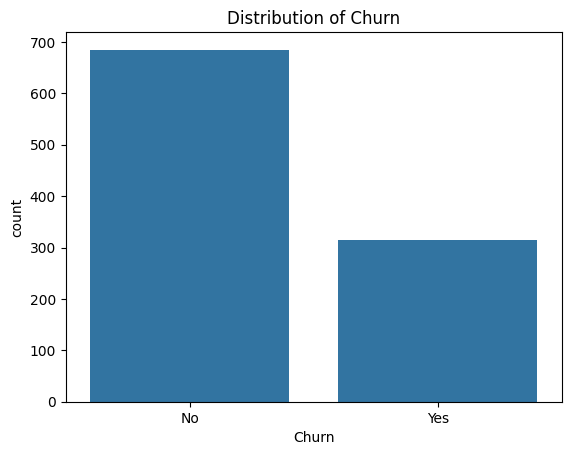

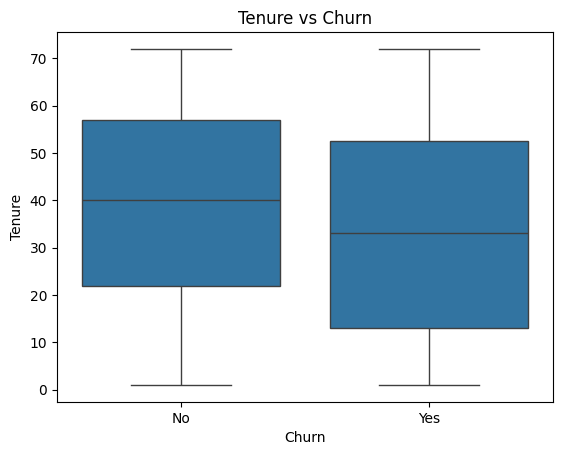

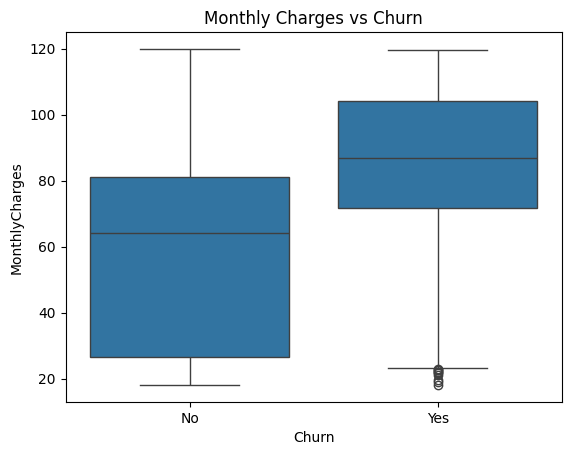

In [3]:
# Visualize Churn distribution
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

# Relationship between Tenure and Churn
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

# Relationship between Monthly Charges and Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

### Step 3: Data Preprocessing for Modeling

Encode categorical variables and split the data into training and testing sets.

In [4]:
# Drop CustomerID as it's not a predictor
df_model = df.drop('CustomerID', axis=1)

# Encode categorical variables
le = LabelEncoder()
for column in df_model.select_dtypes(include=['object']).columns:
    df_model[column] = le.fit_transform(df_model[column])

# Define features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 4: Model Building and Evaluation

Train a Logistic Regression model and evaluate its performance.

In [5]:
# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Confusion Matrix:
[[129  11]
 [ 16  44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91       140
           1       0.80      0.73      0.77        60

    accuracy                           0.86       200
   macro avg       0.84      0.83      0.84       200
weighted avg       0.86      0.86      0.86       200


ROC AUC Score: 0.9226


### Step 5: Discussion and Insights

Based on your analysis and model results, answer the following questions:

1.  **Key Predictors**: Which features seem to be the most important in predicting customer churn? (Hint: Check the coefficients of your Logistic Regression model).
2.  **Marketing Strategy**: If you were the marketing manager, how would you use these predictions to reduce churn? What specific actions would you take for customers identified as 'high risk'?
3.  **Model Improvement**: How could you potentially improve the performance of this churn prediction model?

### 1. Key Predictors
The most important features for predicting customer churn are Contract type, MonthlyCharges, Tenure, and InternetService.  
Customers with month-to-month contracts are more likely to churn because they are not committed long-term.  
Higher monthly charges also increase the probability of churn.  
Customers with shorter tenure are more likely to leave, especially in the first year.  
Internet service type, especially fiber optic, is also associated with higher churn rates.

---

### 2. Marketing Strategy
To reduce churn, the marketing team should focus on high-risk customers identified by the model.  
For customers with high churn probability, the company can offer discounts, personalized promotions, or loyalty programs.  
Customers with month-to-month contracts can be encouraged to switch to long-term plans.  
Additionally, improving customer support and service quality can help retain customers.

---

### 3. Model Improvement
The performance of the churn prediction model can be improved by using more advanced models such as Gradient Boosting or XGBoost.  
Feature engineering can also be enhanced by creating more meaningful variables.  
Including additional data such as customer behavior, complaints, and service usage patterns would improve accuracy.  
Hyperparameter tuning and cross-validation can also help optimize model performance.